# Solution 4B: Rolling-Window Backtest
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from scipy.stats import spearmanr

df = pd.read_parquet("merged.parquet")
df = df[df["month"] >= "2023-01"].copy()

FEATURES = ["momentum", "lag_month", "pb", "roe", "grossmargin",
            "assetturnover", "leverage", "asset_growth", "gp_to_assets"]

for feat in FEATURES:
    df[f"{feat}_rank"] = df.groupby("month")[feat].transform(lambda x: x.rank(pct=True))
df["ret_rank"] = df.groupby("month")["return"].transform(lambda x: x.rank(pct=True))
feat_cols = [f"{f}_rank" for f in FEATURES]
months = sorted(df["month"].unique())
print(f"Data: {len(df):,} rows, {len(months)} months ({months[0]} to {months[-1]})")

Data: 103,931 rows, 35 months (2023-01 to 2025-11)


In [2]:
def run_backtest(df, months, feat_cols, start_month="2024-01", window=None):
    start_idx = next(i for i, m in enumerate(months) if m >= start_month)
    all_preds = []
    for t in range(start_idx, len(months)):
        test_month = months[t]
        if window is None:
            train_data = df[df["month"] < test_month]
        else:
            train_start_idx = max(0, t - window)
            train_months = months[train_start_idx:t]
            train_data = df[df["month"].isin(train_months)]
        test_data = df[df["month"] == test_month]
        if len(train_data) < 100 or len(test_data) < 10:
            continue
        model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=6,
                                  random_state=42, verbosity=-1, n_jobs=-1)
        model.fit(train_data[feat_cols].values, train_data["ret_rank"].values)
        result = test_data[["ticker", "month", "return", "ret_rank", "marketcap"]].copy()
        result["pred"] = model.predict(test_data[feat_cols].values)
        all_preds.append(result)
        print(f"  Predicted {test_month} (train: {len(train_data):,} rows)")
    return pd.concat(all_preds, ignore_index=True)

## Setup: Run expanding-window backtest (from 4A)

In [3]:
preds_exp = run_backtest(df, months, feat_cols, start_month="2024-01", window=None)
preds_exp["decile"] = preds_exp.groupby("month")["pred"].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates="drop") + 1)
pivot_exp = preds_exp.groupby(["month", "decile"])["return"].mean().reset_index().pivot(
    index="month", columns="decile", values="return").sort_index()
ls_exp = pivot_exp[pivot_exp.columns.max()] - pivot_exp[pivot_exp.columns.min()]

  Predicted 2024-01 (train: 37,810 rows)


  Predicted 2024-02 (train: 40,875 rows)


  Predicted 2024-03 (train: 43,892 rows)


  Predicted 2024-04 (train: 46,935 rows)
  Predicted 2024-05 (train: 49,980 rows)


  Predicted 2024-06 (train: 52,953 rows)
  Predicted 2024-07 (train: 55,935 rows)


...

  Predicted 2025-07 (train: 90,254 rows)


  Predicted 2025-08 (train: 92,989 rows)


  Predicted 2025-09 (train: 95,708 rows)


  Predicted 2025-10 (train: 98,458 rows)


  Predicted 2025-11 (train: 101,205 rows)


## 1-2. Rolling-window backtest (12 months)

In [4]:
preds_roll = run_backtest(df, months, feat_cols, start_month="2024-01", window=12)
preds_roll["decile"] = preds_roll.groupby("month")["pred"].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates="drop") + 1)

dec_ret = preds_roll.groupby(["month", "decile"])["return"].mean().reset_index()
dec_avg = dec_ret.groupby("decile")["return"].mean()
dec_std = dec_ret.groupby("decile")["return"].std()

print(f"{'Decile':>8s} {'Mean':>10s} {'Ann. Sharpe':>12s}")
print("-" * 32)
for d in sorted(dec_avg.index):
    sr = dec_avg[d] / dec_std[d] * np.sqrt(12) if dec_std[d] > 0 else 0
    print(f"  D{int(d):2d}    {dec_avg[d]:10.4f} {sr:12.3f}")

pivot_roll = dec_ret.pivot(index="month", columns="decile", values="return").sort_index()
ls_roll = pivot_roll[pivot_roll.columns.max()] - pivot_roll[pivot_roll.columns.min()]
ls_sr_roll = ls_roll.mean() / ls_roll.std() * np.sqrt(12) if ls_roll.std() > 0 else 0
print(f"\n  D10-D1: mean={ls_roll.mean():.4f}, ann. Sharpe={ls_sr_roll:.3f}")

  Predicted 2024-01 (train: 37,810 rows)
  Predicted 2024-02 (train: 37,707 rows)


  Predicted 2024-03 (train: 37,478 rows)
  Predicted 2024-04 (train: 37,288 rows)


  Predicted 2024-05 (train: 37,132 rows)


  Predicted 2024-06 (train: 36,930 rows)


  Predicted 2024-07 (train: 36,739 rows)


...

  Predicted 2025-06 (train: 34,585 rows)
  Predicted 2025-07 (train: 34,319 rows)


  Predicted 2025-08 (train: 34,111 rows)


  Predicted 2025-09 (train: 33,873 rows)


  Predicted 2025-10 (train: 33,697 rows)


  Predicted 2025-11 (train: 33,536 rows)
  Decile       Mean  Ann. Sharpe
--------------------------------
  D 1       -0.0320       -1.703
  D 2        0.0031        0.209
  D 3        0.0040        0.281
  D 4        0.0067        0.493
  D 5        0.0067        0.577
  D 6        0.0067        0.583
  D 7        0.0091        0.769
  D 8        0.0113        0.930
  D 9        0.0150        1.225
  D10        0.0123        0.783

  D10-D1: mean=0.0444, ann. Sharpe=2.476


## 3. Comparison

Metric                  Expanding  Rolling 12m
----------------------------------------------
D10-D1 Spread              0.0497       0.0444
LS Sharpe                   2.723        2.476


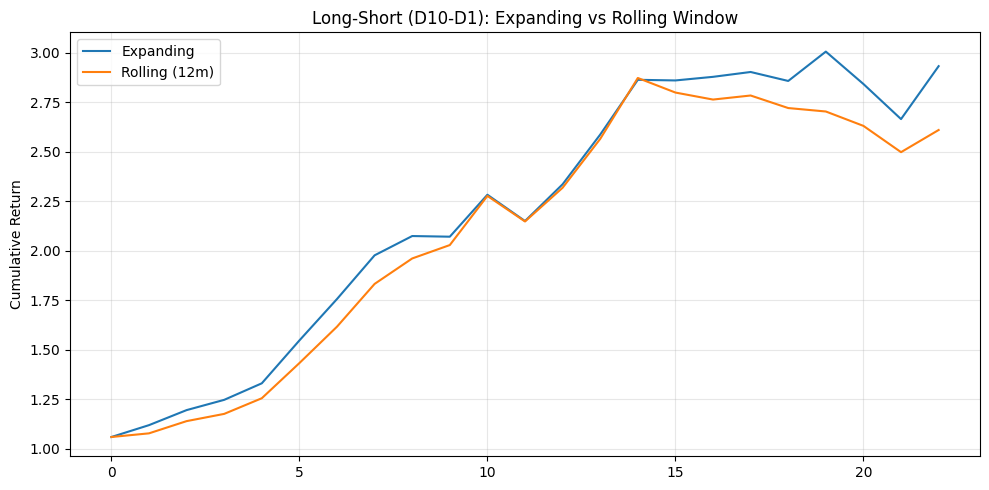

In [5]:
ls_sr_exp = ls_exp.mean() / ls_exp.std() * np.sqrt(12) if ls_exp.std() > 0 else 0
print(f"{'Metric':20s} {'Expanding':>12s} {'Rolling 12m':>12s}")
print("-" * 46)
print(f"{'D10-D1 Spread':20s} {ls_exp.mean():12.4f} {ls_roll.mean():12.4f}")
print(f"{'LS Sharpe':20s} {ls_sr_exp:12.3f} {ls_sr_roll:12.3f}")

common = sorted(set(ls_exp.index) & set(ls_roll.index))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(common)), (1 + ls_exp.loc[common]).cumprod().values, label="Expanding")
ax.plot(range(len(common)), (1 + ls_roll.loc[common]).cumprod().values, label="Rolling (12m)")
ax.set_title("Long-Short (D10-D1): Expanding vs Rolling Window")
ax.set_ylabel("Cumulative Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()